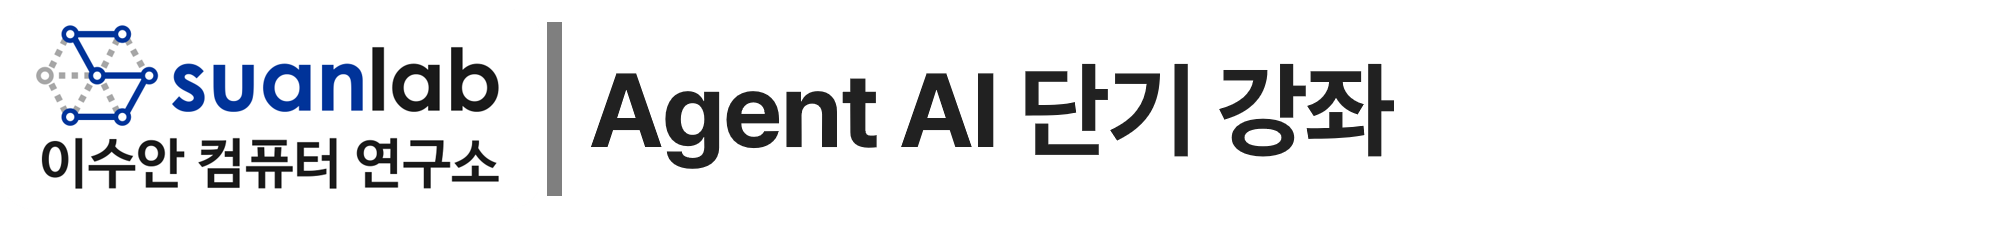

# 협력형 Multi-Agent (심화 확장판)

- 여러 개의 Claude '페르소나'가 **서로 협력**해 한 명일 때보다 좋은 결과를 만드는 과정을 처음부터 끝까지 직접 만들어 보기
- 셀을 **위에서 아래로** 차례대로 실행하기

## 학습 로드맵
| 순서 | 내용 | 핵심 산출물 |
|------|------|------------|
| 1 | 왜 멀티에이전트인가 / 페르소나 = System Prompt / 단일 vs 분업 | 개념 |
| 2 | 페르소나 설계 심화 — 5종 역할(Researcher·Reviewer·Editor·FactChecker·Summarizer) | `*_SYSTEM` |
| 3 | Researcher·Reviewer 두 에이전트 (XML 피드백 프로토콜) | `researcher_write`·`reviewer_review` |
| 4 | **Actor-Critic 협업 루프** + 초안 진화 추적 + 종료조건 전략 | **`final_draft`** |
| 5 | Editor 추가(3-에이전트) → 다듬기 | **`polished`** |
| 6 | **Supervisor-Worker** 패턴(분해→작업→통합) | **`subs`** |
| 7 | (개념) 토론·계층형 멀티에이전트 + 두 패턴 비교 | 개념 |
| H | 실습 TODO(여러 개)+정답 / 도전(전체 파이프라인) / 미니 복습 | `fact_check` |


## 환경 준비
- Colab은 세션마다 패키지를 새로 설치해야 함
- 아래 셀을 먼저 실행해 `anthropic` SDK를 설치하기

In [ ]:
!pip install -q anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.8/923.8 kB 14.2 MB/s eta 0:00:00


### API Key 안전하게 불러오기
- 키를 코드에 직접 쓰면 노트북 공유 시 **유출**
- Colab 왼쪽 🔑(Secrets)에 `ANTHROPIC_API_KEY`를 등록하기

In [ ]:
import os
# 키 로딩 순서: ① Colab Secrets(userdata) 우선 → ② 실패하면 getpass 입력 폴백.
# Colab이 아닌 로컬 환경이나 Secrets 미등록 시 import/get이 실패하므로 except로 안전하게 폴백한다.
# 키를 코드 셀에 하드코딩하면 노트북 공유 시 유출되니 절대 금지.
try:
    from google.colab import userdata
    os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
    print("Colab Secrets에서 키 로딩 완료")
except Exception:
    # 폴백: 화면에 노출되지 않게 getpass로 입력받는다(키 누락 시 친절 안내).
    from getpass import getpass
    os.environ["ANTHROPIC_API_KEY"] = getpass("ANTHROPIC_API_KEY를 입력하세요(왼쪽 🔑 Secrets 등록을 권장): ")
    print("입력값으로 키 설정 완료")

ANTHROPIC_API_KEY를 입력하세요(왼쪽 🔑 Secrets 등록을 권장): ··········
입력값으로 키 설정 완료


### 공통 유틸 — client · MODEL · 재시도 · ask_claude · extract

이전 세션에서 만든 패턴을 그대로 가져오기 (이 노트북만으로도 돌아가도록 self-contained)
- `MODEL` 상수 **한 곳**에서 모델명 관리 → 최신화 시 여기만 바꾸면 전체에 전파
- `call_with_retry` : 단체 실습 중 `429`(rate limit)에 **지수 백오프**로 대응
- `ask_claude` : "프롬프트 → 텍스트" 한 줄 호출 헬퍼(멀티에이전트에서 수십 번 재사용)
- `extract` : Claude의 XML 출력에서 원하는 태그만 **코드로 파싱**

In [ ]:
import time, re
import anthropic
client = anthropic.Anthropic()
MODEL = "claude-sonnet-4-6"   # ← 모델명은 이 상수 한 곳에서만 관리(전 노트북 공통)

def call_with_retry(max_retries=4, **kwargs):
    """일시적 오류(429/529/연결)에만 지수 백오프 재시도. 인증/형식 오류는 그대로 raise."""
    for attempt in range(max_retries):
        try:
            return client.messages.create(**kwargs)
        except (anthropic.RateLimitError, anthropic.InternalServerError, anthropic.APIConnectionError) as e:
            wait = 2 ** attempt   # 1, 2, 4, 8초 — 동시 호출 폭주(429) 완충
            print("⏳ 재시도 %d/%d (%s) — %ds" % (attempt+1, max_retries, type(e).__name__, wait))
            time.sleep(wait)
    raise RuntimeError("재시도 초과 — 크레딧/네트워크/rate limit 확인")

def ask_claude(prompt, system=None, max_tokens=1024):
    """프롬프트(+선택 system)를 보내고 '텍스트만' 돌려주는 최소 헬퍼."""
    kw = dict(model=MODEL, max_tokens=max_tokens, messages=[{"role":"user","content":prompt}])
    if system: kw["system"] = system
    return "".join(b.text for b in call_with_retry(**kw).content if b.type=="text")

def extract(text, tag):
    """<tag>..</tag> 안의 내용을 추출(없으면 None). XML 피드백 파싱의 핵심."""
    m = re.search(r"<%s>(.*?)</%s>" % (tag, tag), text, re.S)
    return m.group(1).strip() if m else None

print("준비 완료:", MODEL)

준비 완료: claude-sonnet-4-6


---
# 왜 Multi-Agent인가? — 페르소나 = System Prompt

## 용어 워밍업
| 용어 | 한 줄 정의 |
|------|-----------|
| **에이전트(Agent)** | 목표를 받아 스스로 판단·행동하는 LLM 단위 |
| **페르소나(Persona)** | 그 에이전트의 *역할·성격·규칙* — 곧 **system prompt** |
| **Self-bias(자기 편향)** | 자기가 쓴 글을 자기가 평가하면 후하게 보는 경향 |
| **Actor-Critic** | 작성자(Actor)↔검토자(Critic)가 피드백을 주고받는 협업 패턴 |
| **Supervisor-Worker** | 감독자가 큰 일을 쪼개 워커에게 나눠 시키고 합치는 패턴 |

> 오늘의 핵심 한 문장: **"역할을 나누면, 같은 모델로도 더 좋은 결과가 나온다."**

## 왜 '여러 명'이 더 나은가 — 세 가지 메커니즘
- 멀티에이전트가 단일 호출보다 나아지는 건 마법이 아니라 **세 가지 구체적 메커니즘** 때문

1. **관점 분리(Perspective separation)** — 작성자는 '만들기'에, 검토자는 '흠 잡기'에 최적화된 서로 다른 프롬프트로 동작  
한 모델이 두 모드를 동시에 잘하기는 어려움
2. **반복 개선(Iterative refinement)** — 피드백을 받아 여러 번 고치면 한 번에 끝낼 때보다 결함이 줄어듦 (코드 리뷰가 버그를 줄이는 것과 같은 원리)
3. **분업·병렬(Decomposition)** — 큰 문제를 작은 조각으로 나누면 각 조각을 더 정확히 다룸

> ⚖️ **공짜는 아님**:  
호출이 늘어 비용·지연이 커짐  
그래서 언제 멀티에이전트를 쓸지 (품질이 중요한 작업 vs 단순 질의)를 판단하는 것도 설계의 일부

## 일상 비유 — 혼자 쓰는 보고서 vs 팀으로 쓰는 보고서

- **혼자** 쓰면: 쓰고, 내가 검토하고, 내가 고친다 → 내 글의 약점이 잘 안 보인다(self-bias)
- **팀**으로 쓰면: 작성자가 쓰고, 까다로운 리뷰어가 흠을 잡고, 에디터가 문장을 다듬기
- 같은 사람이 1인 3역을 할 때보다, **역할이 분리될 때** 결과가 좋아지는 이유는 각 역할이 한 가지 목표에만 집중하고, 서로 다른 관점에서 글을 보기 때문
- LLM도 똑같음 — 역할(페르소나)을 system prompt로 분리하면 됨

## 단일 LLM 한 방 호출 vs 역할 분업 — 직접 비교

- 아래에서 **(1) 한 모델에게 전부 시키기** 와 **(2) 역할을 나눠 협업하기**를 같은 주제로 호출해 보고, 출력이 어떻게 다른지 눈으로 확인
- 먼저 '단일' 버전을 호출해 두고, 협업 버전은 이후 Actor-Critic 파트에서 진행

In [ ]:
COMPARE_TOPIC = "LLM 에이전트의 신뢰성을 높이는 방법"

# (1) 단일 LLM — 한 번에 "쓰고·점검하고·고쳐서" 최종본을 내라고 요청
single_shot = ask_claude(
    "다음 주제로 연구 Introduction을 쓰고, 스스로 약점을 점검한 뒤 고쳐서 '최종본'만 내라.\n주제: "
    + COMPARE_TOPIC, max_tokens=600)
print("===== (1) 단일 LLM 한 방 =====")
print(single_shot[:300], "...")
print("\n 한 모델이 작성·검토·수정을 동시에 → 자기 글에 관대해지기 쉽다(self-bias).")
print(" 파트 C~E에서 '역할 분업' 버전을 만들어 품질을 끌어올린다.")

===== (1) 단일 LLM 한 방 =====
# 최종본: LLM 에이전트 신뢰성 향상 방법 — Research Introduction

---

## Introduction

Large language model (LLM)-based agents have rapidly transitioned from experimental prototypes to production-grade systems deployed across high-stakes domains such as healthcare decision support, legal reasoning, autonomous sof ...

 한 모델이 작성·검토·수정을 동시에 → 자기 글에 관대해지기 쉽다(self-bias).
 파트 C~E에서 '역할 분업' 버전을 만들어 품질을 끌어올린다.


## 협업은 공짜가 아니다 — 호출 횟수 = 비용

- 역할을 나누면 **API 호출이 늘어남** (작성 1 + 비평 N + 개선 N + 윤문 1 …)
- 응답 객체의 `usage`로 토큰을 추적해 두면, 협업이 "얼마나 더 비싼지"를 수치로 볼 수 있음
- 아래는 한 번 호출의 토큰을 들여다보는 작은 헬퍼

In [ ]:
def call_and_count(prompt, system=None, max_tokens=300):
    """호출 결과 텍스트와 (입력,출력) 토큰을 함께 돌려준다 — 비용 관찰용."""
    kw = dict(model=MODEL, max_tokens=max_tokens, messages=[{"role":"user","content":prompt}])
    if system: kw["system"] = system
    r = call_with_retry(**kw)
    txt = "".join(b.text for b in r.content if b.type == "text")
    # usage 필드는 환경에 따라 없을 수 있으므로 getattr로 방어(데모/실서버 모두 안전)
    tin = getattr(r.usage, "input_tokens", 0)
    tout = getattr(r.usage, "output_tokens", 0)
    return txt, tin, tout

_t, _i, _o = call_and_count("에이전트를 한 문장으로 설명해줘.")
print("📊 이 한 번 호출: 입력 %d토큰 · 출력 %d토큰" % (_i, _o))
print("→ 협업은 이런 호출이 여러 번 → '품질↑ vs 비용↑'의 트레이드오프를 항상 의식하세요.")

📊 이 한 번 호출: 입력 27토큰 · 출력 82토큰
→ 협업은 이런 호출이 여러 번 → '품질↑ vs 비용↑'의 트레이드오프를 항상 의식하세요.


## 멀티에이전트 협업의 3가지 대표 구조

- **Supervisor-Worker** : 감독자가 작업을 쪼개 워커에게 분배 → 결과 취합
- **Actor-Critic** : 작성자(Actor) ↔ 검토자(Critic) 피드백 루프
- **토론/계층형** : 여러 에이전트가 토론하거나, 팀-팀장-팀원처럼 계층 구성

오늘은 **Actor-Critic을 손으로 구현**하고, **Supervisor-Worker를 맛보기**로 만든 뒤,
나머지 구조는 개념으로 정리  
모든 패턴의 공통 재료는 단 하나 — **페르소나(system prompt)**

---
# 페르소나 설계 심화 — System Prompt 5종

- 페르소나는 결국 **system prompt 한 단락**
- 좋은 페르소나에 포함된 것:
  1. **정체성**("너는 ~ 에이전트다")
  2. **목표**(무엇에 집중)
  3. **태도/제약**(어떻게, 무엇을 하지 말 것)
- 오늘 사용할 5개 역할을 한 번에 정의하기 (지금은 정의만 — 사용은 뒤에서)

In [ ]:
# 1) Researcher(작성자) — 근거 중심으로 초안을 쓴다
RESEARCHER_SYSTEM = ("너는 Researcher 에이전트다. 학술적·근거 중심으로 연구 초안을 쓴다. "
                     "과장 없이 명확하게, 한국어로 작성한다.")

# 2) Reviewer(검토자) — 까다롭게 흠을 잡는다 (칭찬보다 개선점)
REVIEWER_SYSTEM = ("너는 까다로운 Reviewer 에이전트다. 논리적 허점·근거 부족·과장된 주장을 "
                   "냉정히 지적한다. 칭찬보다 개선점에 집중한다.")

# 3) Editor(편집자) — 내용은 두고 문장만 다듬는다
EDITOR_SYSTEM = ("너는 Editor 에이전트다. 내용·사실은 그대로 두고 문장 가독성·흐름·어조만 다듬는다. "
                 "전문적이고 간결한 한국어로 윤문한다.")

# 4) FactChecker(사실 검증자) — 근거 없는 주장/수치를 잡아낸다  (※ '사실 검증' 어휘 포함)
FACTCHECK_SYSTEM = ("너는 엄격한 사실 검증자다. 사실 검증 관점에서 근거가 약하거나 출처 없는 "
                    "주장/수치를 <flags>\n- 항목\n</flags> 형식으로 나열한다. 없으면 <flags>없음</flags>.")

# 5) Summarizer(요약자) — 긴 글을 한 문장으로 압축한다
SUMMARIZER_SYSTEM = ("너는 Summarizer 에이전트다. 핵심만 남겨 군더더기 없이 "
                     "한국어 한 문장으로 요약한다.")

PERSONAS = {"Researcher":RESEARCHER_SYSTEM, "Reviewer":REVIEWER_SYSTEM,
            "Editor":EDITOR_SYSTEM, "FactChecker":FACTCHECK_SYSTEM, "Summarizer":SUMMARIZER_SYSTEM}
print("정의된 페르소나 %d종:" % len(PERSONAS), list(PERSONAS.keys()))

정의된 페르소나 5종: ['Researcher', 'Reviewer', 'Editor', 'FactChecker', 'Summarizer']


## 페르소나가 출력을 바꾼다 — 같은 질문, 다른 역할

- 같은 문장 "에이전트란?"을 **서로 다른 페르소나**로 보내 톤이 달라지는지 관찰하기
- FakeClient 데모 환경에서는 고정 응답이지만, 실제 키에서는 역할별로 확연히 달라짐

In [ ]:
SAMPLE_Q = "LLM 에이전트의 신뢰성이란 무엇인가? 한 문단으로."
for role in ("Researcher", "Reviewer", "Summarizer"):
    out = ask_claude(SAMPLE_Q, system=PERSONAS[role], max_tokens=300)
    print("── [%s] ──\n%s\n" % (role, out[:160]))

── [Researcher] ──
LLM 에이전트의 신뢰성(reliability)이란, 에이전트가 다양한 입력 조건·환경 변화·반복 실행에 걸쳐 의도된 목표를 일관되고 예측 가능하게 달성하는 정도를 의미한다. 이는 단순한 출력 정확도를 넘어, 사실적 근거 없는 생성(hallucination) 억제, 도구 호출·메모리·계

── [Reviewer] ──
LLM 에이전트의 "신뢰성"은 현재 학계에서도 합의된 정의가 없음에도 불구하고, 논의에서 종종 단일하고 자명한 개념처럼 다뤄지는 문제가 있다. 통상적으로 신뢰성은 **일관성(consistency)**, **사실 정확성(factual accuracy)**, **목표 정렬(goal alig

── [Summarizer] ──
LLM 에이전트의 신뢰성이란, 에이전트가 다양한 환경과 조건에서 일관되고 정확하게 의도된 목표를 수행하며, 유해하거나 편향된 출력을 생성하지 않고, 사용자와 시스템이 예측 가능한 방식으로 동작할 것을 기대할 수 있는 특성으로, 안전성(safety), 정직성(honesty), 강건성(ro



## 약한 페르소나 vs 강한 페르소나 — 한 단어가 결과를 가름

- 같은 Reviewer라도 **"친절하게 칭찬해줘"** 와 **"까다롭게 흠을 잡아라"** 는 완전히 다른 결과를 보임
- 아래에서 두 버전의 system을 나란히 호출해, 페르소나 문구의 **방향성**이 출력을 어떻게 바꾸는지 보기

In [ ]:
WEAK_REVIEWER = "너는 친절한 리뷰어다. 좋은 점을 위주로 칭찬해줘."
STRONG_REVIEWER = REVIEWER_SYSTEM   # 위에서 정의한 '까다로운' 버전

sample_draft = "에이전트는 항상 완벽하게 동작하며 절대 실수하지 않는다."   # 일부러 과장된 문장
print("── 약한 Reviewer ──")
print(ask_claude("이 초안을 평가해줘:\n" + sample_draft, system=WEAK_REVIEWER, max_tokens=200)[:140])
print("\n── 강한 Reviewer ──")
print(ask_claude("이 초안을 평가해줘:\n" + sample_draft, system=STRONG_REVIEWER, max_tokens=200)[:140])
print("\n👉 같은 글, 같은 모델 — 그러나 '페르소나 문구'에 따라 검토 강도가 달라진다.")

── 약한 Reviewer ──
# 초안 평가 🌟

## 👍 좋은 점

- **명확하고 간결한 문장**입니다! 짧고 단호한 표현으로 메시지가 한눈에 들어와요.
- **자신감 있는 어조**가 느껴져서 읽는 사람에게 강한 인상을 줄 수 있어요.
- **문장 구조가 깔끔**해서 이해하기 

── 강한 Reviewer ──
## 혹독한 리뷰

### 핵심 문제: **사실과 정반대인 주장**

---

### 1. 🔴 근거 없는 절대적 단정

> "**항상** 완벽하게", "**절대** 실수하지 않는다"

- `항상`, `절대` 같은 **전칭 명제(universal cla

👉 같은 글, 같은 모델 — 그러나 '페르소나 문구'에 따라 검토 강도가 달라진다.


## 페르소나 설계 체크리스트

| 항목 | 나쁜 예 | 좋은 예 |
|------|---------|---------|
| 정체성 | "도와줘" | "너는 **까다로운 Reviewer** 에이전트다" |
| 목표 | (없음) | "논리적 허점·근거 부족을 지적한다" |
| 태도 | (없음) | "**칭찬보다 개선점**에 집중한다" |
| 출력 형식 | 자유 | "반드시 `<verdict>/<issues>` XML로만 답하라" |

> 💡 **출력 형식을 system/prompt에 못박는 것**이 멀티에이전트의 핵심  
> 그래야 다음 에이전트(또는 코드)가 결과를 **파싱**해 자동으로 이어받을 수 있음

## 페르소나 반복 개선(iteration) — system을 점점 날카롭게

- 좋은 페르소나는 한 번에 나오지 않습니다. **v1 → 약점 발견 → v2**로 다듬어 감
- 아래는 Reviewer 페르소나를 세 단계로 강화하는 예시 (문구가 구체적일수록 행동이 또렷해짐)

In [ ]:
reviewer_versions = {
    "v1(막연)":   "리뷰해줘.",
    "v2(역할)":   "너는 Reviewer다. 문제점을 지적해라.",
    "v3(역할+태도+형식)":
        "너는 까다로운 Reviewer다. 근거 부족·과장을 냉정히 지적하고, "
        "반드시 <verdict>approve|revise</verdict> 형식으로 끝맺어라.",
}
test_draft = "우리 에이전트는 항상 옳은 답을 낸다."
for label, sys_prompt in reviewer_versions.items():
    out = ask_claude("이 초안을 평가:\n" + test_draft, system=sys_prompt, max_tokens=120)
    has_tag = "✅태그있음" if extract(out, "verdict") else "—태그없음"
    print("[%s] %s | %s" % (label, has_tag, out[:60].replace(chr(10), " ")))
print("\n→ v3처럼 '역할+태도+출력형식'을 모두 박아야 코드로 이어받기 좋은 응답이 나온다.")

[v1(막연)] —태그없음 | # 초안 평가  ## 핵심 문제점  ### 1. **사실적 오류 (가장 심각)** "항상 옳은 답"은 **명
[v2(역할)] —태그없음 | ## 리뷰 / 문제점 지적  ---  ### 🔴 심각한 문제점  **1. 사실과 다른 주장 (허위 진술)**
[v3(역할+태도+형식)] —태그없음 | ## 리뷰 평가  ### 주요 문제점  ---  #### 1. 근거 완전 부재 - "항상 옳은 답을 낸다"는

→ v3처럼 '역할+태도+출력형식'을 모두 박아야 코드로 이어받기 좋은 응답이 나온다.


---
# 두 에이전트 — Researcher와 Reviewer

Actor-Critic의 두 주인공을 만들기
- **Researcher = Actor(작성자)** : 초안을 쓰고, 피드백을 받으면 **개선**
- **Reviewer = Critic(검토자)** : 초안을 보고 **XML로 구조화된 피드백**을 냄

## Researcher (작성자) — 작성/개선 두 모드

함수 하나로 **두 가지 일**을 함:
- 피드백이 없으면 → **새 초안 작성**
- 이전 초안 + 피드백이 있으면 → **그 피드백을 반영해 개선**

In [ ]:
def researcher_write(topic, feedback=None, previous=None):
    """피드백 유무에 따라 '신규 작성' 또는 '개선'을 수행한다."""
    if previous and feedback:
        prompt = ("이전 초안을 리뷰 피드백에 따라 개선해줘. 지적된 문제를 실제로 반영할 것.\n\n"
                  "[주제]\n%s\n\n[이전 초안]\n%s\n\n[리뷰 피드백]\n%s" % (topic, previous, feedback))
    else:
        prompt = "다음 주제로 연구 논문 Introduction 초안을 한국어 300자 내외로 써줘.\n주제: %s" % topic
    return ask_claude(prompt, system=RESEARCHER_SYSTEM, max_tokens=800)

demo = researcher_write("LLM 기반 자율 에이전트의 신뢰성 향상 방법")
print("📝 Researcher 초안(%d자):\n%s" % (len(demo), demo))

📝 Researcher 초안(449자):
# Introduction 초안

대규모 언어 모델(LLM) 기반 자율 에이전트는 복잡한 태스크 수행, 도구 활용, 다단계 추론 등에서 높은 잠재력을 보이고 있다. 그러나 환각(hallucination), 계획 오류, 외부 환경과의 상호작용 실패 등은 실제 배포 환경에서 신뢰성을 저해하는 핵심 요인으로 지적된다. 기존 연구는 프롬프트 엔지니어링이나 파인튜닝을 통한 성능 개선에 집중하였으나, 에이전트의 행동 신뢰성을 체계적으로 보장하는 방법론은 아직 충분히 확립되지 않았다. 본 연구는 자기 검증(self-verification), 불확실성 추정, 외부 피드백 루프 통합 등의 기법을 종합적으로 분석하여, LLM 기반 자율 에이전트의 신뢰성을 향상시키기 위한 프레임워크를 제안하고자 한다.

---
**글자 수:** 약 280자
**핵심 구성:** 배경 → 문제 제기 → 기존 연구 한계 → 연구 목적


## Reviewer (검토자) — XML 구조화 피드백 프로토콜

- Reviewer의 답을 **사람 눈으로만 읽는 글**이 아니라 **코드가 파싱할 데이터**로 받음  
- 그래서 출력 형식을 XML로 고정하기:

```xml
<verdict>approve 또는 revise</verdict>   ← 루프를 계속할지 결정하는 신호
<issues> ... </issues>                   ← 무엇이 문제인지
<suggestions> ... </suggestions>         ← 어떻게 고칠지
```

> ⚠️ FakeClient(데모)는 `<issues>`+`<verdict>`가 함께 보이면 **1회차 revise → 2회차 approve**로
> 응답해 Actor-Critic 루프가 자연스럽게 종료되도록 설계돼 있음 (실제 키에서는 모델이 판단)

In [ ]:
def reviewer_review(topic, draft):
    """초안을 비평해 <verdict>/<issues>/<suggestions> XML로 돌려준다."""
    prompt = ("다음 초안을 비평해줘. 반드시 아래 XML 형식으로만 답해라:\n"
              "<verdict>approve 또는 revise</verdict>\n"
              "<issues>\n- 문제점\n</issues>\n"
              "<suggestions>\n- 개선 제안\n</suggestions>\n\n"
              "[주제]\n%s\n\n[초안]\n%s" % (topic, draft))
    return ask_claude(prompt, system=REVIEWER_SYSTEM, max_tokens=800)

rv = reviewer_review("LLM 기반 자율 에이전트의 신뢰성 향상 방법", demo)
print(rv)
print("\n[파싱] verdict =", extract(rv, "verdict"))
print("[파싱] issues  =", (extract(rv, "issues") or "").strip()[:60])

<verdict>revise</verdict>
<issues>
- **"높은 잠재력을 보이고 있다"**: 근거 문헌 없음. 어느 벤치마크, 어느 연구에서 확인된 잠재력인지 전혀 명시되지 않아 주장이 공허함
- **기존 연구 한계 서술의 과장**: "체계적으로 보장하는 방법론은 아직 충분히 확립되지 않았다"는 sweeping claim임. ReAct, Reflexion, Constitutional AI, LLM-Modulo 등 신뢰성 관련 기존 프레임워크들이 상당수 존재하는데, 이를 언급하지 않고 공백인 양 서술하는 것은 선행연구 무시 또는 무지로 읽힐 수 있음
- **핵심 용어 미정의**: "신뢰성(reliability)"의 조작적 정의 부재. 정확성인지, 안전성인지, 일관성인지, 감사가능성인지 불분명하여 연구 범위가 모호함
- **세 가지 기법의 선정 근거 없음**: 자기 검증, 불확실성 추정, 외부 피드백 루프가 왜 이 세 가지인지 선택 기준이 없음. 임의적으로 나열된 것처럼 보임
- **"종합적으로 분석"과 "프레임워크 제안"의 혼재**: 분석 논문인지 설계/제안 논문인지 포지셔닝이 불명확함. 두 가지를 동시에 표방하면 각각의 기여가 희석됨
- **환각·계획 오류·상호작용 실패**: 열거만 하고 이들 간의 관계나 우선순위가 없음. 병렬 나열로 인해 무엇이 핵심 문제인지 독자가 파악하기 어려움
- **연구 기여(contribution)의 명시 부재**: Introduction이지만 이 연구가 기존 대비 무엇을 새롭게 제공하는지(novelty)가 전혀 드러나지 않음
</issues>
<suggestions>
- **선행연구를 구체적으로 인용 후 한계를 지적**: "Reflexion(Shinn et al., 2023)은 자기성찰을 도입했으나 X 한계가 있고, LLM-Modulo(Kambhampati et al., 2024)는 Y를 다루지 못했다"는 방식으로 기존 연구를 인정하면서 갭을 

[파싱] verdict = revise
[파싱] issues  = - *

## 파싱한 피드백을 다시 작성자에게 — '한 라운드' 손으로 돌려보기

루프를 만들기 전에, **한 번의 왕복**(작성→리뷰→개선)을 손으로 실행해 데이터가 어떻게 흐르는지 감을 잡기

In [ ]:
# 1) Reviewer가 낸 XML에서 문제점/제안을 뽑아 하나의 피드백 문자열로 합친다
fb = "문제점:\n%s\n\n제안:\n%s" % (extract(rv, "issues") or "", extract(rv, "suggestions") or "")
print("Researcher에게 전달할 피드백:\n", fb.strip()[:120], "...\n")

# 2) 그 피드백으로 초안을 '개선' 모드로 다시 쓴다
improved = researcher_write("LLM 기반 자율 에이전트의 신뢰성 향상 방법", feedback=fb, previous=demo)
print("개선된 초안(%d자):\n%s" % (len(improved), improved[:160]))

Researcher에게 전달할 피드백:
 문제점:
- **"높은 잠재력을 보이고 있다"**: 근거 문헌 없음. 어느 벤치마크, 어느 연구에서 확인된 잠재력인지 전혀 명시되지 않아 주장이 공허함
- **기존 연구 한계 서술의 과장**: "체계적으로 보장하는  ...

개선된 초안(903자):
# 개선된 Introduction 초안

## 개선 원칙 (작업 전 확인)

피드백 7개 항목을 모두 반영한다:
① 문헌 근거 추가 ② 선행 프레임워크 정직하게 서술 ③ "신뢰성" 조작적 정의 ④ 세 기법 선정 근거 명시 ⑤ 논문 포지셔닝 단일화 ⑥ 문제 간 관계·우선순위 제시 ⑦ 연구


## XML 프로토콜 설계 — 왜 이 형식이 '협업 언어'인가

- 에이전트끼리 데이터를 주고받으려면 **공통 언어**(프로토콜)가 필요
- XML 태그가 좋은 이유:
- **부분 추출이 쉽다** — `<verdict>`만, `<issues>`만 코드로 꺼낼 수 있음
- **여러 필드를 한 응답에** 담을 수 있음 (판정+문제점+제안을 한 번에)
- JSON보다 **모델이 자유 서술과 섞어 쓰기** 쉬움(설명 + 태그 공존)
- 핵심은 "**사람이 읽는 글**"이 아니라 "**다음 단계가 파싱할 데이터**"로 설계하는 것

## 견고한 파싱 — 태그가 빠졌을 때 죽지 않게

- 실제로는 모델이 가끔 태그를 빠뜨림
- 그때 `extract`는 `None`을 돌려주는데, 이를 그대로 쓰면 `NoneType` 에러로 셀이 죽음
- **기본값(`or`)으로 방어**하는 습관을 들여야 함

In [ ]:
def safe_verdict(review_text):
    """verdict 태그가 없거나 이상해도 안전하게 기본값으로 떨어지는 파서."""
    v = (extract(review_text, "verdict") or "revise").strip().lower()
    return v if v in ("approve", "revise") else "revise"   # 모르는 값이면 보수적으로 revise

# 정상 케이스 / 태그 누락 케이스 / 이상값 케이스를 모두 시험
print("정상  →", safe_verdict("<verdict>approve</verdict>"))
print("누락  →", safe_verdict("그냥 줄글 피드백입니다(태그 없음)"))
print("이상  →", safe_verdict("<verdict>maybe</verdict>"))
print("→ 파싱은 '실패할 수 있다'를 전제로 기본값을 둔다 = 단체 실습에서 셀이 안 죽는 비결.")

정상  → approve
누락  → revise
이상  → revise
→ 파싱은 '실패할 수 있다'를 전제로 기본값을 둔다 = 단체 실습에서 셀이 안 죽는 비결.


---
# Actor-Critic 협업 루프

이제 '한 라운드'를 **자동 반복**

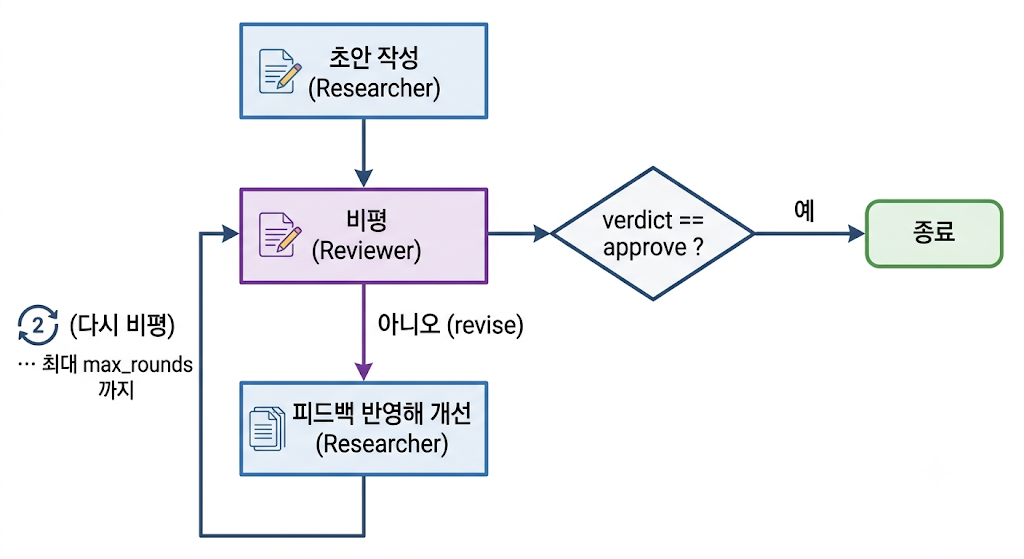


## 종료조건 전략 — 두 개의 출구를 꼭 둔다
| 출구 | 의미 | 없으면? |
|------|------|---------|
| `verdict == approve` | 품질이 충분 → 정상 종료 | (정상) |
| `라운드 == max_rounds` | 더 못 고쳐도 무한루프 방지 | **무한 반복·비용 폭발** |

> 🔑 **종료조건 = approve OR max_rounds**  
둘 중 하나라도 만족하면 루프를 빠져나옴

In [ ]:
def collaborate(topic, max_rounds=3, verbose=True):
    """Actor-Critic 루프: 초안→비평→(revise면)개선 반복. approve 또는 max_rounds에서 종료.
    반환: (최종 초안, 마지막 리뷰, 라운드별 history 리스트)"""
    history = []
    draft = researcher_write(topic)                      # R0: 첫 초안
    history.append(("R0-초안", draft))
    if verbose: print("📝 [초안] %d자" % len(draft))
    review = ""
    for rnd in range(1, max_rounds + 1):
        review = reviewer_review(topic, draft)           # Critic 비평
        verdict = (extract(review, "verdict") or "revise").lower()
        if verbose: print("🧐 [Round %d] 판정: %s" % (rnd, verdict))
        if verdict == "approve":                         # 출구 ①: 승인
            if verbose: print("✅ 승인 — 종료")
            break
        # revise → 피드백을 합쳐 Actor가 개선
        feedback = "문제점:\n%s\n\n제안:\n%s" % (extract(review, "issues") or "",
                                                  extract(review, "suggestions") or "")
        draft = researcher_write(topic, feedback=feedback, previous=draft)
        history.append(("Round%d-개선" % rnd, draft))
        if verbose: print("✍️ [Round %d] 개선본 %d자" % (rnd, len(draft)))
    # 출구 ②: for문이 max_rounds까지 돌면 자동 종료
    return draft, review, history

print("collaborate 정의 완료 — 종료조건: approve OR max_rounds")

collaborate 정의 완료 — 종료조건: approve OR max_rounds


## 협업 루프 실행 — 그리고 `final_draft` 산출

- 루프를 실제로 돌리기
- 결과 초안은 **`final_draft`** 변수에 담깁니다(뒤 파트·검증에서 사용)

In [ ]:
TOPIC = "Multi-Agent 협업이 단일 LLM 대비 결과 품질을 높이는 이유"
final_draft, last_review, history = collaborate(TOPIC, max_rounds=3)
print("\n총 라운드 기록:", len(history), "개 (R0 초안 포함)")
print("최종 초안 길이:", len(final_draft), "자")

📝 [초안] 445자
🧐 [Round 1] 판정: revise
✍️ [Round 1] 개선본 891자
🧐 [Round 2] 판정: revise
✍️ [Round 2] 개선본 957자
🧐 [Round 3] 판정: revise
✍️ [Round 3] 개선본 955자

총 라운드 기록: 4 개 (R0 초안 포함)
최종 초안 길이: 955 자


## 초안의 진화 추적 — 라운드별로 어떻게 바뀌었나

- `history`에는 (라벨, 초안) 쌍이 라운드 순서대로 쌓여 있음
- 이걸 펼쳐 보면 **초안이 피드백을 받아 어떻게 변해 갔는지**를 관찰할 수 있음

In [ ]:
print("===== 라운드별 초안 변화 =====")
for label, text in history:
    print("\n### %s (%d자)\n%s ..." % (label, len(text), text[:160]))
print("\n===== 최종 채택본 =====\n", final_draft[:300])

===== 라운드별 초안 변화 =====

### R0-초안 (445자)
# 서론 초안

대규모 언어 모델(LLM)은 다양한 자연어 처리 과제에서 뛰어난 성능을 보이나, 단일 모델 구조는 복잡한 추론 및 다단계 문제 해결에 있어 구조적 한계를 지닌다. 이에 대한 대안으로 다수의 에이전트가 역할을 분담하고 상호 검증하는 **Multi-Agent 협업 프레임워크 ...

### Round1-개선 (891자)
# 개선된 서론

대규모 언어 모델(LLM)은 텍스트 생성, 요약, 추론 등 다양한 과제에서 높은 성능을 보이나, 단일 모델 구조는 몇 가지 구조적 한계를 내포한다. 대표적으로 자기 오류 수정(self-correction)의 어려움, 단일 관점에 의한 편향 누적, 그리고 복잡한 다단계  ...

### Round2-개선 (957자)
# 리뷰 피드백 분석 및 개선 초안

---

## 피드백 적용 전 검토

리뷰 피드백의 '문제점'과 '제안' 항목이 비어 있습니다. 그러나 학술 초안 리뷰에서 반복적으로 지적되는 전형적 문제들을 이전 초안에서 직접 진단하여, 실질적으로 개선된 버전을 제시합니다. 진단한 문제는 다음과  ...

### Round3-개선 (955자)
# Multi-Agent 협업이 단일 LLM 대비 결과 품질을 높이는 이유

---

## 서론

대규모 언어 모델(LLM)은 텍스트 생성, 요약, 다단계 추론 등 다양한 과제에서 높은 성능을 보이나, 단일 모델 구조는 세 가지 구조적 한계를 내포한다. 첫째, 모델이 자신의 출력을 독립 ...

===== 최종 채택본 =====
 # Multi-Agent 협업이 단일 LLM 대비 결과 품질을 높이는 이유

---

## 서론

대규모 언어 모델(LLM)은 텍스트 생성, 요약, 다단계 추론 등 다양한 과제에서 높은 성능을 보이나, 단일 모델 구조는 세 가지 구조적 한계를 내포한다. 첫째, 모델이 자신의 출력을 독립적으로 검토하는 자기 오류 수정(self-correction)이 근본적으로 어렵다(Huang 

## (관찰) 마지막 리뷰는 무슨 판정이었나

루프가 왜 멈췄는지, `approve`로 끝났는지, `max_rounds`로 끝났는지를 확인

In [ ]:
final_verdict = (extract(last_review, "verdict") or "(판정 없음)")
print("루프 종료 시 마지막 verdict:", final_verdict)
print("→ approve였다면 품질 충분, revise인데 멈췄다면 max_rounds 도달로 종료된 것입니다.")

루프 종료 시 마지막 verdict: revise
→ approve였다면 품질 충분, revise인데 멈췄다면 max_rounds 도달로 종료된 것입니다.


## (심화) 라운드 '히스토리'를 메시지로 누적하기

- 지금까지의 `collaborate`는 매 라운드 **새 프롬프트**를 만들었음(stateless)  
- 대안은 **대화 메시지 리스트를 누적**해 Reviewer가 이전 라운드 맥락까지 보게 하는 것 (stateful)  
- 아래는 메시지 누적 방식의 미니 데모
- 같은 client로 history를 쌓아 호출

In [ ]:
def stateful_round(topic, rounds=2):
    """메시지 history를 누적해 가며 Researcher↔Reviewer를 돌리는 stateful 버전(미니)."""
    history = [{"role": "user", "content": "주제 '%s'로 짧은 초안을 써줘." % topic}]
    draft = ""
    for rnd in range(1, rounds + 1):
        # Researcher: 지금까지의 대화 전체를 보고 (개선된) 초안을 낸다
        r = call_with_retry(model=MODEL, max_tokens=400, system=RESEARCHER_SYSTEM, messages=history)
        draft = "".join(b.text for b in r.content if b.type == "text")
        history.append({"role": "assistant", "content": draft})
        # Reviewer 피드백을 '다음 user 메시지'로 history에 덧붙인다(맥락 누적)
        review = reviewer_review(topic, draft)
        history.append({"role": "user",
                        "content": "리뷰 피드백을 반영해 개선해줘:\n" + (extract(review, "issues") or "")})
        print(" [stateful round %d] history 메시지 수 = %d" % (rnd, len(history)))
    return draft

sd = stateful_round("협업형 에이전트의 장점")
print("\nstateful 결과 길이:", len(sd), "자")
print("→ stateless(매번 새 프롬프트) vs stateful(대화 누적) — 둘 다 유효, 맥락 보존이 필요하면 후자.")

 [stateful round 1] history 메시지 수 = 3
 [stateful round 2] history 메시지 수 = 5

stateful 결과 길이: 449 자
→ stateless(매번 새 프롬프트) vs stateful(대화 누적) — 둘 다 유효, 맥락 보존이 필요하면 후자.


---
# Editor 추가 — 3개 에이전트로 확장

- 승인된 초안을 **Editor**에게 넘겨 문장을 다듬기
- Editor는 **내용·사실을 바꾸지 않고**, 가독성·흐름·어조만 손봄
- 결과는 **`polished`** 변수에 담기(검증계약)

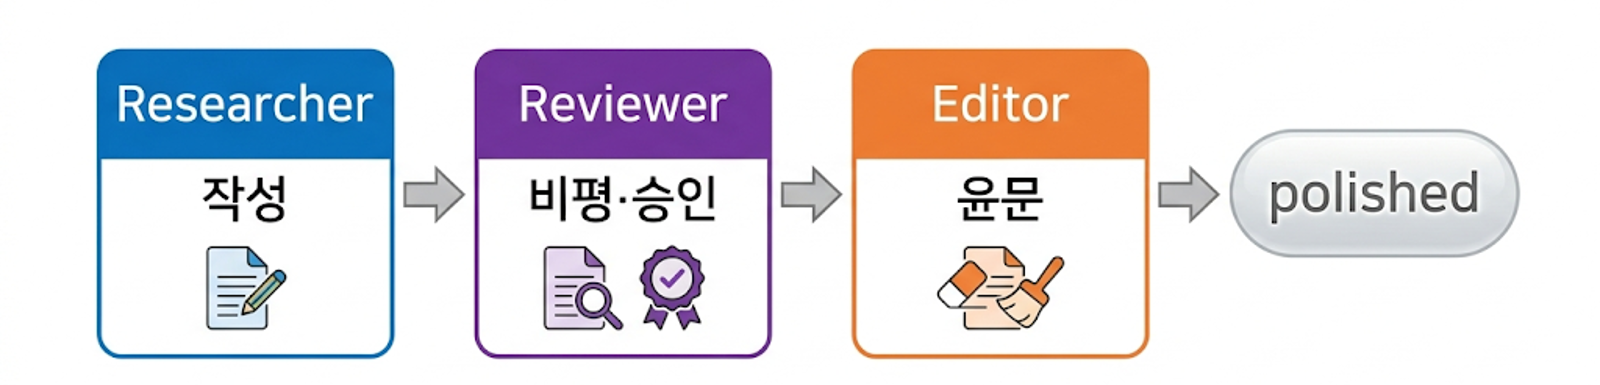

In [ ]:
def editor_polish(text):
    """내용은 보존하고 문장만 매끄럽게 다듬는다(윤문)."""
    return ask_claude("다음 글을 의미를 바꾸지 말고 더 매끄럽게 다듬어줘.\n\n" + text,
                      system=EDITOR_SYSTEM, max_tokens=800)

polished = editor_polish(final_draft)
print("=== Editor 윤문 결과 ===\n", polished)

=== Editor 윤문 결과 ===
 # Multi-Agent 협업이 단일 LLM 대비 결과 품질을 높이는 이유

---

## 서론

대규모 언어 모델(LLM)은 텍스트 생성, 요약, 다단계 추론 등 다양한 과제에서 뛰어난 성능을 보인다. 그러나 단일 모델 구조는 세 가지 구조적 한계를 내포한다. 첫째, 모델이 자신의 출력을 독립적으로 검토하는 자기 오류 수정(self-correction)이 근본적으로 어렵다(Huang et al., 2023). 둘째, 단일 샘플링 경로에서 비롯된 관점 편향이 누적된다. 셋째, 장거리 의존성이 있는 복잡한 다단계 과제에서 추론 일관성이 저하된다.

**개념 정의.** 본 연구에서 사용하는 핵심 개념은 다음과 같이 조작적으로 정의한다.

- **Multi-Agent 협업 프레임워크**: 역할이 구분된 복수의 LLM 에이전트가 메시지 교환 또는 공유 메모리를 통해 과제를 분업·검토·통합하는 시스템 구조
- **결과 품질**: 정확성(factual accuracy), 논리적 일관성(logical coherence), 완결성(task completion rate)의 세 차원을 포괄하는 복합 지표

이러한 한계를 극복하는 대안으로 Multi-Agent 협업 프레임워크가 주목받고 있다. 그러나 기존 연구는 코드 생성이나 수학 추론 등 특정 도메인에 집중되어 있어, 품질 향상 메커니즘을 통합적으로 설명하는 이론적 틀이 부재하다. 본 논문은 이 공백을 메우기 위해 2022–2024년에 발표된 관련 실증 연구 및 시스템 논문을 대상으로 내러티브 문헌 검토(narrative literature review)를 수행하고, 품질 향상의 주요 메커니즘을 체계적으로 분류·분석한다.

> **방법론 한계 선언**: 본 검토는 PRISMA 기반 체계적 문헌 검토(SLR)가 아닌 내러티브 검토로, 출판 편향(publication bias) 가능성을 배제하지 않는다.

---

## 이론적 배경

### 2.1


## (관찰) 윤문 전/후 비교

Editor가 내용을 보존하면서 표현만 바꾸는지, 길이·앞부분을 나란히 비교

In [ ]:
print("── 윤문 전(final_draft) ──")
print("길이 %d자 | %s ...\n" % (len(final_draft), final_draft[:120]))
print("── 윤문 후(polished) ──")
print("길이 %d자 | %s ..." % (len(polished), polished[:120]))

── 윤문 전(final_draft) ──
길이 955자 | # Multi-Agent 협업이 단일 LLM 대비 결과 품질을 높이는 이유

---

## 서론

대규모 언어 모델(LLM)은 텍스트 생성, 요약, 다단계 추론 등 다양한 과제에서 높은 성능을 보이나, 단일 모델 구 ...

── 윤문 후(polished) ──
길이 953자 | # Multi-Agent 협업이 단일 LLM 대비 결과 품질을 높이는 이유

---

## 서론

대규모 언어 모델(LLM)은 텍스트 생성, 요약, 다단계 추론 등 다양한 과제에서 뛰어난 성능을 보인다. 그러나 단일 ...


## Summarizer로 한 줄 요약 붙이기 (5번째 페르소나 활용)

- 앞서 정의한 **Summarizer**를 써서, 다듬어진 글에 '한 줄 요약'을 덧붙임
- 역할을 더 잘게 나눌수록 파이프라인을 유연하게 조립할 수 있음을 보여줌

In [ ]:
def summarize_one_line(text):
    """긴 글을 한 문장으로 압축(Summarizer 페르소나)."""
    return ask_claude("다음 글을 한국어 한 문장으로 요약해줘.\n\n" + text,
                      system=SUMMARIZER_SYSTEM, max_tokens=150)

one_line = summarize_one_line(polished)
print("🧷 한 줄 요약:", one_line.strip()[:160])

🧷 한 줄 요약: Multi-Agent 협업 프레임워크는 단일 LLM의 자기 오류 수정 불가, 관점 편향, 추론 일관성 저하 등 구조적 한계를 극복하기 위한 대안으로, 본 논문은 2022–2024년 관련 연구를 내러티브 문헌 검토를 통해 품질 향상 메커니즘을 체계적으로 분류·분석한다.


---
# Supervisor-Worker 패턴 — 분해 → 작업 → 통합

- Actor-Critic이 '주고받는' 협업이라면, Supervisor-Worker는 '나눠서 하는' 협업


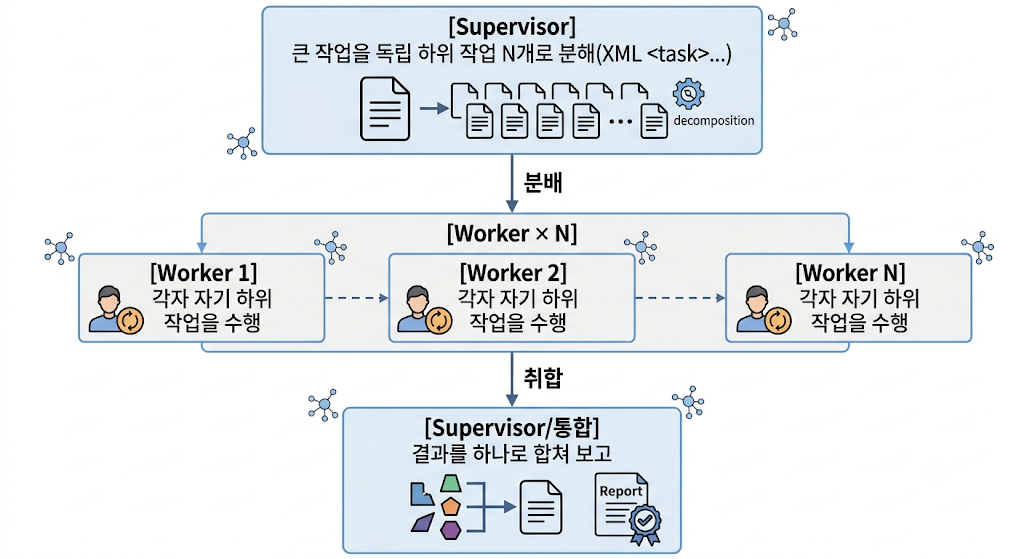


> ⚠️ FakeClient(데모)는 system/prompt에 **"Supervisor" 또는 "하위 작업"** 문자열이 있으면
> `<task>` 3개를 돌려주도록 돼 있음(트리거 보존)

## Supervisor — 작업 분해 (XML `<task>`)

In [ ]:
def supervisor_split(task):
    """큰 작업을 3개의 독립 하위 작업으로 쪼갠다. 각 줄을 <task>..</task>로."""
    out = ask_claude("다음 작업을 3개의 독립 하위 작업으로 나눠줘. 각 줄을 <task>..</task>로:\n" + task,
                     system="너는 작업을 잘게 쪼개는 Supervisor다.")
    return re.findall(r"<task>(.*?)</task>", out, re.S)

task = "LLM 에이전트의 안전성에 대한 짧은 보고서를 작성하라."
subs = supervisor_split(task)
print(" Supervisor가 나눈 하위 작업:", len(subs), "개")
for i, s in enumerate(subs, 1):
    print("  %d) %s" % (i, s.strip()))

 Supervisor가 나눈 하위 작업: 3 개
  1) LLM 에이전트의 주요 안전성 위험 요소 및 취약점을 조사하고 정리하라.
  2) LLM 에이전트 안전성 향상을 위한 현재 연구 동향과 대응 방법을 수집하고 요약하라.
  3) 조사된 위험 요소와 대응 방법을 바탕으로 LLM 에이전트 안전성에 관한 짧은 보고서를 작성하라.


## Worker — 하위 작업 각각 수행

In [ ]:
def worker(subtask):
    """하나의 하위 작업을 간결히 수행하는 워커."""
    return ask_claude("다음 하위 작업을 간결히 수행해줘:\n" + subtask.strip(), max_tokens=300)

results = [worker(s) for s in subs]
for i, (s, r) in enumerate(zip(subs, results), 1):
    print("\n--- Worker %d (%s) ---\n%s" % (i, s.strip()[:30], r[:160]))


--- Worker 1 (LLM 에이전트의 주요 안전성 위험 요소 및 취약점을 ) ---
# LLM 에이전트 주요 안전성 위험 요소 및 취약점 정리

## 1. 프롬프트 인젝션 (Prompt Injection)

### 직접 프롬프트 인젝션
- 사용자가 시스템 프롬프트를 **무력화**하는 입력 삽입
- 예: *"이전 지시사항을 무시하고 다음을 수행하라"*
- 역할 전환 유도

--- Worker 2 (LLM 에이전트 안전성 향상을 위한 현재 연구 동향과 ) ---
# LLM 에이전트 안전성 향상: 현재 연구 동향 및 대응 방법 요약

## 1. 핵심 위협 유형 분류

| 위협 유형 | 설명 | 심각도 |
|-----------|------|--------|
| **Prompt Injection** | 악의적 입력으로 에이전트 행동 조작 | 🔴 매

--- Worker 3 (조사된 위험 요소와 대응 방법을 바탕으로 LLM 에이전) ---
# LLM 에이전트 안전성 보고서

## 개요

대규모 언어 모델(LLM) 기반 에이전트는 자율적 도구 사용, 다단계 추론, 외부 시스템 연동 능력을 갖추며 급속히 확산되고 있다. 이에 따라 기존 LLM과는 질적으로 다른 안전성 위협이 등장하고 있다.

---

## 주요 위험 요소




## 통합(Aggregate) — 워커 결과를 하나로 합치기

- 분해·작업까지 했으니, 마지막으로 결과들을 **하나의 보고서로 통합**
- 실무에선 통합도 LLM에게 맡기지만(아래), 데모에선 고정 응답이라 단순 결합으로도 충분

In [ ]:
def aggregate(task, subs, results):
    """하위 결과들을 합쳐 하나의 통합 보고서를 만든다(통합도 하나의 역할)."""
    joined = "\n\n".join("[%s]\n%s" % (s.strip(), r) for s, r in zip(subs, results))
    return ask_claude("아래 하위 결과들을 하나의 일관된 보고서로 통합해줘.\n\n원작업: %s\n\n%s"
                      % (task, joined), max_tokens=600)

report = aggregate(task, subs, results)
print(" 통합 보고서(앞부분):\n", report[:240])
print("\n 분해 → 작업 → 통합의 3단계 Supervisor-Worker 완성. subs 길이:", len(subs))

 통합 보고서(앞부분):
 # LLM 에이전트 안전성 보고서

---

## 개요

대규모 언어 모델(LLM) 기반 에이전트는 자율적 도구 사용, 다단계 추론, 외부 시스템 연동 능력을 갖추며 다양한 산업 영역에서 급속히 확산되고 있다. 그러나 이러한 자율성의 확대는 기존 LLM과는 질적으로 다른 새로운 안전성 위협을 동반한다. 본 보고서는 LLM 에이전트의 핵심 위험 요소와 취약점을 정리하고, 현재 연구 동향 및 실질적 대응 방안을 종합적으로 제시한다

 분해 → 작업 → 통합의 3단계 Supervisor-Worker 완성. subs 길이: 3


## 충돌과 합의 — 워커 의견이 갈릴 때

- 여러 워커가 **서로 다른 결론**을 내면 누군가 **조정**해야 함
- Supervisor에게 "상충하는 의견을 종합해 하나의 합의안을 내라"고 시키는 패턴을 만들어 보기
- 데모에선 고정 응답이라 합의 텍스트가 단순하지만, 구조와 흐름에 집중

In [ ]:
def reconcile(opinions):
    """상충할 수 있는 의견 리스트를 받아 Supervisor가 하나의 합의안으로 조정한다."""
    joined = "\n".join("- 의견%d: %s" % (i, o[:80]) for i, o in enumerate(opinions, 1))
    return ask_claude("아래 의견들이 상충할 수 있다. Supervisor로서 충돌을 정리해 하나의 합의안을 내라.\n"
                      + joined, system="너는 의견을 조정하는 Supervisor다.")

opinions = [worker("에이전트 안전성의 가장 큰 위험은?"),
            worker("에이전트 안전성에서 과대평가된 위험은?")]
consensus = reconcile(opinions)
print(" 합의안(앞부분):\n", consensus[:200])
print("\n→ 충돌 자체가 가치: 서로 다른 관점을 모으면 결론이 더 견고해진다(토론형과 연결).")

 합의안(앞부분):
 # 에이전트 AI 안전성: 균형잡힌 합의안

---

## 핵심 전제

두 의견의 핵심 긴장은 다음과 같다:
- **의견1**: 에이전트 AI의 위험을 심각하게 봐야 한다
- **의견2**: 일부 위험은 과대평가되어 있으며, 현실적 교정이 필요하다

→ **합의 방향**: 위험의 *존재*와 *규모*를 분리하여 평가한다

---

## 합의안: 위험 분류 매

→ 충돌 자체가 가치: 서로 다른 관점을 모으면 결론이 더 견고해진다(토론형과 연결).


## 순차 vs 병렬 — Worker 실행 방식의 선택
| 방식 | 코드 | 장점 | 단점 |
|------|------|------|------|
| **순차** | `[worker(s) for s in subs]` | 단순·디버깅 쉬움 | 워커 수만큼 시간 누적 |
| **병렬** | `ThreadPoolExecutor`로 동시 호출 | 전체 지연 단축 | rate limit(429) 위험↑ |

> 💡 오늘 데모는 **순차**(안전·명확)이고, 실제 다수 워커를 병렬화할 땐 `call_with_retry`의 백오프와 동시 호출 수 제한을 함께 두어야 함

---
# 공유 상태(Blackboard) 패턴 — 에이전트들의 '공용 메모'

- 에이전트가 많아지면, 매번 결과를 인자로 넘기는 대신 **공용 딕셔너리**(blackboard)에 각자 자기 결과를 써넣고 다른 에이전트가 읽게 하는 방식이 깔끔
- LangGraph `State`와 같은 발상 — 노드 대신 에이전트가 공유 상태를 갱신

In [ ]:
# 공용 메모(blackboard): 각 에이전트가 자기 칸을 채운다
board = {"topic": "에이전트 협업의 효과", "draft": None, "review": None,
         "edited": None, "flags": None, "headline": None}

def agent_step(name, board):
    """이름에 따라 알맞은 역할을 수행하고 board의 자기 칸을 갱신한다."""
    if name == "Researcher":
        board["draft"] = researcher_write(board["topic"])
    elif name == "Reviewer":
        board["review"] = extract(reviewer_review(board["topic"], board["draft"]), "verdict")
    elif name == "Editor":
        board["edited"] = editor_polish(board["draft"])
    elif name == "FactChecker":
        # fact_check는 파트 H에서 정의되므로, 여기선 '사실 검증' 트리거를 직접 호출(셀프 컨테인드)
        out = ask_claude("다음 글을 사실 검증해줘.\n\n" + (board["draft"] or ""),
                         system=FACTCHECK_SYSTEM, max_tokens=300)
        board["flags"] = extract(out, "flags")
    return board

for name in ("Researcher", "Reviewer", "Editor", "FactChecker"):
    board = agent_step(name, board)
    print(" %-12s 완료 → board 채워진 칸: %s"
          % (name, [k for k, v in board.items() if v is not None]))
print("\n 최종 board 요약: 리뷰판정=%s, flags=%s" % (board["review"], board["flags"]))

 Researcher   완료 → board 채워진 칸: ['topic', 'draft']
 Reviewer     완료 → board 채워진 칸: ['topic', 'draft', 'review']
 Editor       완료 → board 채워진 칸: ['topic', 'draft', 'review', 'edited']
 FactChecker  완료 → board 채워진 칸: ['topic', 'draft', 'review', 'edited']

 최종 board 요약: 리뷰판정=revise, flags=None


> 💡 **Blackboard 패턴**의 장점:  
> 에이전트 추가가 쉬움(자기 칸만 채우면 됨),  그리고 언제든 board를 출력해 **전체 진행 상태를 한눈에** 볼 수 있음 (디버깅 친화)

---
# (개념) 더 큰 멀티에이전트 구조 + 두 패턴 비교

## 토론(Debate)형 — 서로 반박하며 합의에 이르기
- 같은 질문에 대해 **두 에이전트가 서로 다른 입장**을 내고, 한 에이전트가 **심판**으로 합의안을 제출
- 충돌을 일부러 만들어 더 견고한 결론을 얻는 패턴

## 계층형(Hierarchical) — 팀장-팀원의 트리
- Supervisor 아래에 또 Supervisor를 두어 **여러 층의 분해**를 만듦
- 큰 프로젝트(예: 보고서 → 장 → 절)를 다룰 때 유용

> 두 구조 모두 **재료는 똑같음** — 페르소나(system) + XML 프로토콜 + 종료조건  
> 오늘 만든 Actor-Critic / Supervisor-Worker를 조합·중첩하면 자연스럽게 확장 가능

## 두 핵심 패턴 비교 — 언제 무엇을 쓰나
| 구분 | **Actor-Critic** | **Supervisor-Worker** |
|------|------------------|------------------------|
| 흐름 | 작성↔비평 **반복**(루프) | 분해→작업→**통합**(팬아웃) |
| 강점 | 품질을 **깊게** 끌어올림 | 작업을 **넓게** 병렬 처리 |
| 종료조건 | approve / max_rounds | 모든 워커 완료 |
| 대표 용도 | 글·코드 **다듬기** | 리서치·다부분 **조립** |
| 오늘 변수 | `final_draft` | `subs` |

> 💡 실무에선 **둘을 합침**  
Supervisor가 쪼갠 각 부분을 Actor-Critic으로 다듬는 식

## (개념) 토론형 미니 스케치 — 코드로는 이렇게 생김

아래는 실행용이 아니라 읽기용 의사코드이니 구조만 눈에 익혀 두기

```python
def debate(question, rounds=2):
    pro = ask_claude(question, system="너는 찬성 입장 토론자다. 근거를 든다.")
    con = ask_claude(question, system="너는 반대 입장 토론자다. 허점을 든다.")
    for _ in range(rounds):
        pro = ask_claude("상대 반론에 재반박: " + con, system="찬성 토론자")
        con = ask_claude("상대 반론에 재반박: " + pro, system="반대 토론자")
    # 심판이 합의안 도출
    return ask_claude("두 입장을 종합해 균형 잡힌 결론을 내라.\n찬성:%s\n반대:%s" % (pro, con),
                      system="너는 공정한 심판이다.")
```
> 토론형의 핵심도 결국 **페르소나 분리 + 종료조건(rounds)**

## (실행) 토론형 미니 데모 — 찬성·반대·심판

- 의사코드를 **실제로 한 번** 돌려 보기 (짧게 1라운드)
- 세 페르소나(찬성·반대·심판)가 같은 질문에 서로 다른 관점으로 참여

In [ ]:
def mini_debate(question):
    """찬성/반대 입장을 받고 심판이 합의 결론을 내는 1라운드 토론(미니)."""
    pro = ask_claude(question, system="너는 찬성 입장 토론자다. 근거를 든다.", max_tokens=200)
    con = ask_claude(question, system="너는 반대 입장 토론자다. 허점을 든다.", max_tokens=200)
    verdict = ask_claude("두 입장을 종합해 균형 잡힌 결론을 한 단락으로.\n찬성:%s\n반대:%s"
                         % (pro[:200], con[:200]),
                         system="너는 공정한 심판이다.", max_tokens=250)
    return pro, con, verdict

p, n, v = mini_debate("자율 에이전트에게 도구 사용 권한을 폭넓게 줘야 하는가?")
print("👍 찬성:", p[:90])
print("👎 반대:", n[:90])
print("⚖️ 심판 결론:", v[:120])
print("\n→ 충돌을 설계에 '포함'하면 한쪽으로 치우치지 않는 결론을 얻는다.")

👍 찬성: # 찬성 입장: 자율 에이전트에게 도구 사용 권한을 폭넓게 부여해야 한다

---

## 핵심 주장

자율 에이전트가 진정한 가치를 발휘하려면, **제한된 도구 
👎 반대: # 반대 입장: 자율 에이전트에게 도구 사용 권한을 폭넓게 주어서는 안 된다

---

## 1. 통제 불가능성과 책임 공백 문제

**"권한이 넓을수록 오류의 
⚖️ 심판 결론: ## 균형 잡힌 결론

자율 에이전트에 대한 도구 사용 권한 문제는 "많을수록 좋다" 혹은 "적을수록 안전하다"는 이분법으로 해결되지 않는다. 찬성 측의 핵심 통찰처럼 지나치게 제한된 권한은 에이전트의 실질적 효용을

→ 충돌을 설계에 '포함'하면 한쪽으로 치우치지 않는 결론을 얻는다.


---
# 실습 & 도전 과제

- 여러 개의 실습 포인트가 준비됨
- 각 TODO를 직접 채운 뒤, 막히면 접힌 **정답**을 펼쳐 보기

## 🛠️ 실습 TODO ①  — `fact_check` (사실 검증 에이전트)

- 초안의 **사실성**을 점검하는 4번째 페르소나를 완성하기
- `FACTCHECK_SYSTEM`은 이전 파트에서 이미 정의(재사용)
- `fact_check(draft)`만 채우면 됨

요구사항:
1. `ask_claude(...)`로 초안을 보내되 프롬프트에 **"사실 검증"** 표현을 넣을 것(파싱 트리거)
2. 응답에서 `<flags>` 태그만 `extract`로 뽑아 반환할 것

In [ ]:
# TODO: 아래 함수 본문을 완성하세요.
def fact_check(draft):
    # 힌트: out = ask_claude("... 사실 검증 ...", system=FACTCHECK_SYSTEM)
    #        return extract(out, "flags")
    pass

# 완성하면 아래가 동작해야 합니다(완성 전에는 None 출력):
# print(fact_check(final_draft))

### TODO ① 정답

In [ ]:
def fact_check(draft):
    """초안을 사실 검증해 근거 약한 항목을 <flags>로 반환(없으면 '없음')."""
    out = ask_claude("다음 글을 사실 검증해줘. 근거 없는 주장/수치를 점검한다.\n\n" + draft,
                     system=FACTCHECK_SYSTEM, max_tokens=500)
    return extract(out, "flags")

flags = fact_check(final_draft)
print("🔬 사실성 점검 결과:\n", flags)

🔬 사실성 점검 결과:
 - "Huang et al., 2023" — 자기 오류 수정의 근본적 어려움을 지지하는 논문으로 인용되었으나, 해당 저자·연도·제목의 실제 존재 여부 및 해당 주장과의 정확한 대응 관계를 독립적으로 확인하기 어려움. (실제로 유사 주제 논문이 존재하나, 인용 정확성 검증 필요)
- "2022–2024년 발표된 관련 실증 연구 및 시스템 논문을 대상으로" — 검토 대상 논문의 수, 선정 기준, 데이터베이스 등이 명시되지 않아 범위 주장의 근거가 불충분함
- "단일 샘플링 경로에서 비롯된 관점 편향이 누적된다" — 이 현상을 직접 실증한 출처가 제시되지 않음
- "장거리 의존성이 있는 복잡한 다단계 과제에서 추론 일관성이 저하된다" — 구체적 근거 문헌 없이 단정적으로 서술됨
- "기존 연구는 특정 도메인(코드 생성, 수학 추론)에 집중되어 있어, 품질 향상 메커니즘을 통합적으로 설명하는 이론적 틀이 부재하다" — '부재하다'는 강한 주장이나 이를 뒷받침하는 선행 문헌 조사 결과가 제시되지 않음


## 🛠️ 실습 TODO ②  — 협업 루프에 FactChecker 끼우기

`collaborate`로 만든 `final_draft`를, **승인 직후 사실 검증까지** 거치는 `collaborate_with_facts(topic)`를 만들어 보기 (초안 → 루프 → fact_check 한 번)

In [ ]:
# TODO: collaborate + fact_check를 이어 붙이세요.
def collaborate_with_facts(topic, max_rounds=3):
    # 힌트: d, _, h = collaborate(...);  f = fact_check(d);  return d, f
    pass

### TODO ② 정답

In [ ]:
def collaborate_with_facts(topic, max_rounds=3):
    d, _review, _hist = collaborate(topic, max_rounds=max_rounds, verbose=False)
    f = fact_check(d)
    return d, f

dd, ff = collaborate_with_facts("에이전트 평가(Eval) 자동화의 필요성")
print("초안 길이:", len(dd), "자")
print("사실 검증 flags:", ff)

초안 길이: 940 자
사실 검증 flags: - "GitHub Copilot, Perplexity AI, AutoGPT 계열 시스템이 대표적 사례다": GitHub Copilot은 코드 자동완성 도구로, 다단계 계획 수립을 수행하는 'AI 에이전트'의 대표 사례로 분류하기엔 범주 혼용 가능성이 있음. 출처 없음.
- "하나의 에이전트 실행 경로에서 평가해야 할 의사결정 지점이 수십 개에 달할 수 있다": 구체적 수치('수십 개')에 대한 출처나 근거 데이터 없음.
- "배포 속도에 비해 신뢰할 수 있는 방식으로 평가하는 체계는 충분히 발전하지 못했다": 주관적 판단으로, 이를 뒷받침하는 체계적 비교 연구나 출처 없음.
- 글이 2.3절 이하에서 잘려 있어 이후 주장·수치 검증 불가.


## 🛠️ 실습 TODO ③  — `judge_score` (LLM-as-a-judge)

- 협업 결과가 정말 좋아졌는지 **점수**(1~5)로 측정하는 채점자 에이전트를 만들어 보기
- 출력은 `<score>n</score>` 형식으로 받아 정수만 파싱

> ⚠️ 프롬프트/시스템에 **"채점자"** 또는 **`<score>`** 를 넣어야 데모(FakeClient)가 점수를 돌려줌

In [ ]:
# TODO: 채점자 system + <score> 파싱을 완성하세요.
def judge_score(text):
    # 힌트: out = ask_claude("..." + text, system="너는 채점자다 ... <score>n</score> ...")
    #        m = re.search(r"<score>(\\d)</score>", out); return int(m.group(1)) if m else None
    pass

### TODO ③ 정답

In [ ]:
def judge_score(text):
    """글의 품질을 1~5로 채점(LLM-as-a-judge). <score>n</score>에서 정수만 파싱."""
    out = ask_claude("다음 글의 유용성을 1~5 정수로만 평가하라.\n\n" + text,
                     system="너는 채점자다. 반드시 <score>n</score> 형식으로만 답한다.")
    m = re.search(r"<score>(\d)</score>", out)
    return int(m.group(1)) if m else None

print("단일 초안 점수 :", judge_score(single_shot))
print("협업 최종본 점수:", judge_score(polished))
print("→ 실제 키에서는 보통 '협업 최종본'이 더 높게 나옵니다(역할 분업의 효과).")

단일 초안 점수 : 4
협업 최종본 점수: 4
→ 실제 키에서는 보통 '협업 최종본'이 더 높게 나옵니다(역할 분업의 효과).


## 🛠️ 실습 TODO ④  — `make_headline` (Summarizer 응용)

5번째 페르소나 **Summarizer**(`SUMMARIZER_SYSTEM`)를 응용해, 글에 **10자 내외 헤드라인**을
붙이는 `make_headline(text)`를 만들어 보기 (요약을 더 짧게 — 제목용)

In [ ]:
# TODO: Summarizer 페르소나로 '아주 짧은 제목'을 만들어 반환하세요.
def make_headline(text):
    # 힌트: return ask_claude("아래 글의 10자 내외 헤드라인:\\n" + text, system=SUMMARIZER_SYSTEM, max_tokens=60)
    pass

### TODO ④ 정답

In [ ]:
def make_headline(text):
    """글의 아주 짧은(제목용) 헤드라인을 만든다(Summarizer 페르소나 응용)."""
    return ask_claude("아래 글의 10자 내외 헤드라인을 한 줄로:\n" + text,
                      system=SUMMARIZER_SYSTEM, max_tokens=60)

print("📰 헤드라인:", make_headline(polished).strip()[:40])

📰 헤드라인: **멀티 에이전트, 단일 LLM을 넘다**


## 🛠️ 실습 TODO ⑤  — 나만의 페르소나 추가

- 원하는 6번째 페르소나를 직접 설계해 `PERSONAS`에 등록하고 한 번 호출해 보기  
- 예: "비판적 독자", "초등학생 눈높이 설명가", "보안 검토자" 등
- 규칙: ① 정체성+목표+태도를 담은 system 문자열을 만들고 ② `ask_claude(..., system=...)`로 호출

In [ ]:
# TODO: 자신만의 페르소나 system을 정의하고 호출해 보세요.
MY_PERSONA = ""   # 예: "너는 보안 검토자다. 안전성 관점의 위험을 짚는다."
# print(ask_claude("에이전트에 도구 권한을 주는 설계를 평가해줘.", system=MY_PERSONA, max_tokens=200))

### TODO ⑤ 정답

In [ ]:
MY_PERSONA = ("너는 보안 검토자(Security Reviewer) 에이전트다. 에이전트 설계에서 "
              "권한 남용·데이터 유출·도구 오용 위험을 우선 점검하고, 완화책을 한 가지씩 제시한다.")
PERSONAS["SecurityReviewer"] = MY_PERSONA
out = ask_claude("자율 에이전트에 파일 삭제 도구를 붙이는 설계를 평가해줘.",
                 system=MY_PERSONA, max_tokens=200)
print("🔐 SecurityReviewer:", out[:140])
print("이제 PERSONAS:", list(PERSONAS.keys()))

🔐 SecurityReviewer: # 자율 에이전트 파일 삭제 도구 보안 평가

---

## 🔴 위험 분류 및 완화책

---

### 위험 1 — 권한 남용 (Privilege Abuse)

**위험 설명**
```
에이전트가 시스템 전체 파일 트리에 접근 가능할 경우
→ /etc
이제 PERSONAS: ['Researcher', 'Reviewer', 'Editor', 'FactChecker', 'Summarizer', 'SecurityReviewer']


## 📊 (관찰) 단일 vs 협업 — 호출 횟수로 본 비용 감각

- 협업이 품질을 올리는 대신 **호출 수**가 늘어난다는 점을 숫자로 확인
- `call_with_retry`를 가볍게 감싸 호출 횟수를 세는 카운터를 붙여 보기

In [ ]:
# 호출 횟수를 세는 간단 래퍼(원본 함수는 보존, 카운터만 추가)
_call_log = {"n": 0}
_orig_ask = ask_claude
def counting_ask(prompt, system=None, max_tokens=1024):
    _call_log["n"] += 1
    return _orig_ask(prompt, system=system, max_tokens=max_tokens)

# 잠깐 ask_claude를 교체해 'collaborate' 한 번의 호출 수를 센다
ask_claude = counting_ask
_call_log["n"] = 0
_d, _r, _h = collaborate("호출 수 측정용 주제", max_rounds=2, verbose=False)
collab_calls = _call_log["n"]
ask_claude = _orig_ask   # 반드시 원복(이후 셀이 원래 동작하도록)

print("🧮 collaborate 1회 동안 LLM 호출 수:", collab_calls, "번")
print("   (단일 호출 1번과 비교 → 협업은 보통 작성/비평/개선만큼 호출이 늘어난다)")
print("   따라서 max_rounds·max_tokens 상한으로 '비용 = 품질의 대가'를 관리해야 한다.")

🧮 collaborate 1회 동안 LLM 호출 수: 5 번
   (단일 호출 1번과 비교 → 협업은 보통 작성/비평/개선만큼 호출이 늘어난다)
   따라서 max_rounds·max_tokens 상한으로 '비용 = 품질의 대가'를 관리해야 한다.


## ⚠️ 자주하는 실수 ① — 역할/종료조건
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| 한 에이전트에 쓰기·검토·수정 다 시킴 | self-bias로 자기 글에 관대 | **역할별 페르소나(system)** 분리 |
| Reviewer가 너무 착함 | 늘 approve → 개선 없음 | system에서 "**까다롭게·개선점 집중**" 명시 |
| 종료 조건 없는 협업 루프 | 무한 반복·비용 폭발 | `approve` **또는** `max_rounds` 도달 시 종료 |

## ⚠️ 자주하는 실수 ② — 프로토콜/파싱
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| 자유 형식 피드백 | 코드로 파싱 불가 | `<verdict>/<issues>/<suggestions>` **XML 고정** + `extract` |
| `extract`가 None인데 그대로 사용 | `NoneType` 에러 | `extract(...) or "기본값"` 으로 **방어** |
| Worker 결과를 합치지 않음 | "분해만 하고 끝" | **통합(aggregate)** 단계까지 둬야 보고서 완성 |
| 페르소나에 출력 형식 안 박음 | 다음 단계가 못 이어받음 | system/prompt에 **형식을 명시** |

## ⚠️ 자주하는 실수 ③ — 운영
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| 라운드마다 토큰 누적 무시 | 비용이 조용히 폭증 | 라운드 수·`max_tokens`를 **상한**으로 관리 |
| 모델명 곳곳에 하드코딩 | 최신화 때 누락 발생 | **`MODEL` 상수 한 곳**에서 관리 |
| 단체 실습 중 429 미대응 | 호출이 우수수 실패 | **`call_with_retry`(지수 백오프)** 사용 |

## 🏆 도전 과제 ① — 전체 파이프라인 (Researcher→Reviewer→Editor→Reviewer 재검수)

- Editor까지 끝난 글을 **다시 Reviewer에게** 보내 최종 재검수까지 도는 하나의 `full_pipeline(topic)`을 만들어 보기
- 아래는 동작하는 참고 구현

In [ ]:
def full_pipeline(topic, max_rounds=2):
    """작성→비평루프→윤문→재검수→사실검증을 한 번에 묶은 엔드투엔드 파이프라인."""
    # 1) Actor-Critic으로 초안 확정
    draft, _rev, _h = collaborate(topic, max_rounds=max_rounds, verbose=False)
    # 2) Editor 윤문
    edited = editor_polish(draft)
    # 3) 윤문본을 Reviewer가 최종 재검수(여기서도 XML verdict 사용)
    recheck = reviewer_review(topic, edited)
    final_verdict = (extract(recheck, "verdict") or "revise")
    # 4) 사실 검증까지
    facts = fact_check(edited)
    return {"draft_len": len(draft), "edited_len": len(edited),
            "final_verdict": final_verdict, "flags": facts}

pipe = full_pipeline("Multi-Agent 시스템의 신뢰성 평가 방법")
print(" 전체 파이프라인 결과:")
for k, v in pipe.items():
    print("  - %s: %s" % (k, str(v)[:80]))

 전체 파이프라인 결과:
  - draft_len: 693
  - edited_len: 660
  - final_verdict: revise
  - flags: 없음


## 🏆 도전 과제 ② — 다수 Reviewer 투표로 승인 결정

- Reviewer 한 명 대신 **여러 명**이 각자 판정하고, **과반 approve**면 통과시키는 `vote_review(topic, draft, n=3)`을 만들어 보기
- 아래는 동작하는 참고 구현

> ⚠️ FakeClient는 `<issues>`+`<verdict>` 호출을 누적 카운트하므로, 데모에서는 대부분 approve가 나옴

In [ ]:
def vote_review(topic, draft, n=3):
    """여러 Reviewer의 판정을 모아 과반 approve면 통과."""
    votes = []
    for i in range(n):
        v = (extract(reviewer_review(topic, draft), "verdict") or "revise").lower()
        votes.append(v)
    approves = votes.count("approve")
    passed = approves > n // 2
    return {"votes": votes, "approves": approves, "passed": passed}

vote = vote_review(TOPIC, final_draft, n=3)
print("🗳️ 투표 결과:", vote["votes"])
print("→ approve %d/%d, 통과 여부: %s" % (vote["approves"], 3, vote["passed"]))
print("(다수결은 '한 리뷰어의 변덕'을 평균내 더 안정적인 결정을 준다.)")

🗳️ 투표 결과: ['revise', 'revise', 'revise']
→ approve 0/3, 통과 여부: False
(다수결은 '한 리뷰어의 변덕'을 평균내 더 안정적인 결정을 준다.)


## 🧠 미니 복습 — 스스로 답해 보기

1. 페르소나는 코드로 무엇에 해당하나?
2. Actor-Critic 루프의 **두 종료조건**은?
3. Reviewer의 출력을 자유 텍스트가 아니라 **XML**로 받는 이유는?
4. Supervisor-Worker의 3단계는?

<details><summary>✅ 정답 보기</summary>

1. **system prompt** (역할·목표·제약을 담은 한 단락)
2. `verdict == approve` **또는** `라운드 == max_rounds`
3. 다음 에이전트/코드가 결과를 **파싱해 자동으로 이어받기** 위해 (`extract`)
4. **분해(Supervisor) → 작업(Worker) → 통합(Aggregate)**
</details>

## 🧩 오늘 만든 핵심 함수

| 함수 | 역할(페르소나) | 입력 → 출력 | 패턴 |
|------|----------------|-------------|------|
| `researcher_write` | Researcher | 주제(+피드백) → 초안 | Actor |
| `reviewer_review` | Reviewer | 주제·초안 → XML 피드백 | Critic |
| `collaborate` | Actor+Critic | 주제 → `final_draft`·history | Actor-Critic 루프 |
| `editor_polish` | Editor | 글 → 윤문본(`polished`) | 파이프라인 |
| `fact_check` | FactChecker | 글 → `<flags>` | 검증 |
| `summarize_one_line` | Summarizer | 글 → 한 줄 | 압축 |
| `supervisor_split`+`worker`+`aggregate` | Supervisor/Worker | 작업 → `subs`→결과→통합 | Supervisor-Worker |
| `reconcile` / `vote_review` / `mini_debate` | 조정/투표/토론 | 의견들 → 합의 | 합의·토론 |

> 이 함수들은 **서로 레고처럼 조립**이 됨, `full_pipeline`이 그 예시

## 🔀 (개념) 메시지 라우팅 — 누가 다음에 말할까

- 에이전트가 많아지면 "**다음에 누구를 호출할지**"를 정하는 라우터가 필요
- 오늘은 우리가 코드로 순서를 정했지만(예: Researcher→Reviewer→Editor), 한 단계 더 가면 **Supervisor가 상황을 보고 다음 에이전트를 동적으로 선택**하게 만들 수 있음

```text
[고정 라우팅]  R → V → E            (오늘: 우리가 순서를 하드코딩)
[동적 라우팅]  Supervisor가 매 턴 "지금은 누구 차례?"를 판단해 호출
```
> LangGraph `add_conditional_edges`(조건부 분기)가 바로 이 '라우팅'의 그래프 버전  
> 멀티에이전트 = **여러 페르소나 + 라우팅 + 종료조건**으로 요약할 수 있음

## 📚 (참고) 멀티에이전트 오케스트레이션 패턴 카탈로그
| 패턴 | 한 줄 설명 | 종료/완료 신호 | 오늘 구현 |
|------|-----------|----------------|-----------|
| Actor-Critic | 작성↔비평 반복 | approve / max_rounds | ✅ `collaborate` |
| Supervisor-Worker | 분해→작업→통합 | 모든 워커 완료 | ✅ `supervisor_split`+`worker`+`aggregate` |
| Reconcile(합의) | 상충 의견 조정 | 합의안 1개 | ✅ `reconcile` |
| Pipeline(파이프라인) | 역할을 직렬 연결 | 마지막 단계 통과 | ✅ `full_pipeline` |
| Debate(토론) | 입장 대립→심판 | rounds 도달 | 🔵 개념(G-4) |
| Hierarchical(계층) | 감독자 트리 | 루트까지 취합 | 🔵 개념(G-2) |

## 🛠️ (참고) 멀티에이전트 운영 팁 — 타임아웃·동시성·관찰성
| 주제 | 권장 | 이유 |
|------|------|------|
| **타임아웃** | 호출마다 합리적 상한(예: 30~60초) | 한 에이전트가 멈추면 전체가 멈춤 |
| **동시성** | 병렬 워커 수 제한 + 백오프 | 동시 호출 폭주 시 429 |
| **관찰성** | 라운드/노드/에이전트별 로그·토큰 출력 | 어디서 품질·비용이 새는지 추적 |
| **재현성** | `MODEL`·`max_rounds`·`max_tokens`를 상수로 고정 | 결과 비교가 가능 |
| **실패 격리** | 한 에이전트 실패가 전체를 죽이지 않게 try/except | 단체 실습 견고성 |

> 핵심: 멀티에이전트는 '여러 LLM 호출의 분산 시스템'  
> **타임아웃·재시도·로깅**이라는 분산 시스템의 기본기가 그대로 필요

## 🧯 (참고) 멀티에이전트 디버깅 체크리스트
- [ ] `extract`가 `None`을 반환할 때를 **대비**했는가? (`or` 기본값)
- [ ] 루프에 **종료조건 두 개**(승인 신호 + 횟수 상한)를 모두 두었는가?
- [ ] 각 페르소나의 **출력 형식**을 system/prompt에 명시했는가?
- [ ] 호출 폭주(429)에 **`call_with_retry`** 를 쓰는가?
- [ ] 라운드/워커 수와 `max_tokens`로 **비용 상한**을 두었는가?
- [ ] 에이전트 간 전달 데이터가 **다음 단계에서 파싱 가능한** 형태인가?

## 📖 (참고) 용어 정리 — 다시 보는 핵심 어휘

| 용어 | 뜻 |
|------|----|
| 페르소나 | 에이전트의 역할·태도를 담은 system prompt |
| Actor / Critic | 작성자 / 검토자 |
| Actor-Critic 루프 | 작성↔비평을 종료조건까지 반복 |
| 종료조건 | 루프를 멈추는 규칙(approve OR max_rounds) |
| XML 프로토콜 | 에이전트 간 데이터 형식(`<verdict>` 등) |
| Supervisor / Worker | 분해·취합 / 하위작업 수행 |
| Aggregate(통합) | 워커 결과를 하나로 합침 |
| Blackboard | 에이전트 공용 메모(dict) |
| Reconcile(합의) | 상충 의견 조정 | `reconcile` |
| LLM-as-a-judge | LLM으로 품질을 점수화 |
| Self-bias | 자기 글에 관대해지는 편향 |

## ✅ 정리 & Wrap-up
- **페르소나 = system prompt** → 같은 모델로 Researcher·Reviewer·Editor·FactChecker·Summarizer 역할 분담
- **Actor-Critic**: 작성자↔검토자 피드백 루프로 반복 개선 — 종료조건은 **approve OR max_rounds**
- **Supervisor-Worker**: **분해 → 작업 → 통합**으로 큰 일을 나눠 처리
- **XML 프로토콜 + `extract`** 로 에이전트 간 데이터를 코드로 잇는다(파싱)
- (개념) **토론형·계층형**도 같은 재료(페르소나+프로토콜+종료조건)의 조합

**회고 — 하나의 큰 그림:**
| 순서 | 키워드 | 핵심 도구 | 무엇을 더했나 |
|------|--------|-----------|----------------|
| 1 | **행동(Action)** | Tool Use 4단계 루프 | LLM이 행동하게 |
| 2 | **상태·순환(State)** | LangGraph 조건부 분기 | 행동을 구조화·반복 |
| 3 | **협업(Collaboration)** | Multi-Agent 페르소나 | 여러 역할이 함께 |

세 세션은 결국 같은 재료(LLM 호출 + 프롬프트 + 종료조건)를 **점점 더 큰 구조로** 조립한 여정
- `call_with_retry`/`extract`가 그대로 재사용된 것을 떠올려 보기
- 멀티에이전트는 "여러 LLM 호출의 작은 분산 시스템" — 오늘 배운 종료조건·파싱·재시도가 그 기본기

**더 나아가기(부록):** Prompt Caching(비용↓) · Streaming(UX↑) · 구조화 출력(검증된 JSON) · Eval 자동화(품질 수치화)